# Is my simulator producing the right distribution? Goodness of fit when only the *score* is known

## The problem

Many of the most valuable distributions in science and industry are known only **up to a constant**:

* **Molecular simulation / materials / drug discovery**: the Boltzmann distribution
  `p(x) ∝ exp(-U(x)/kT)` of a molecule's configurations. Computing the normalising constant (the
  partition function) is hopeless, but the *force* `-∇U` is exactly what the simulator computes.
* **Bayesian models in production**: the posterior is `prior × likelihood` divided by an unknown
  constant; MCMC samplers are supposed to draw from it.
* **Energy-based generative models** in machine learning: the model *is* an unnormalised density.

In all three, a sampler produces draws that are *supposed* to follow `p`. Samplers have step sizes,
approximations and bugs. How do you check them without the constant? Stein's identity: for the true
`p`, `E_p[s(X) f(X) + f'(X)] = 0` for every nice `f`, where `s = ∇ log p` is the **score** — and the
score does not depend on the constant. The sequential kernelized Stein discrepancy test
(Martinez-Taboada & Ramdas, AISTATS 2025) bets on that identity: it learns from past draws the
function `f` on which the sampler's output looks least like `p`, and bets on it. `expectation.stein`
adds a certified bound on the payoff from a Lipschitz constant of the score, so the bet is fair by
construction.

## What you will see

Two samplers for the double-well potential `U(x) = (x^2 - 1)^2`, `beta = 1` (a toy of a molecule
with two stable conformations):

* an **exact** sampler (inverse CDF on a fine grid) — should pass;
* the **tamed unadjusted Langevin algorithm** with a large step size — a realistic production
  shortcut that is *biased*: it converges, but not to `p`. Should fail.

Then a machine-learning style check: is my data Gaussian, or does it have heavier tails than my
model assumes?

## One important caveat

The test's null is about the law of each new draw *given everything seen so far*. Consecutive states
of a single MCMC chain are autocorrelated and violate that, so we use **one draw per independent
chain** (many short chains), which is also how production samplers are typically parallelised.

## Glossary

* **score**: `∇ log p(x)`; for Boltzmann, `-beta ∇U(x)`, i.e. the force divided by temperature.
* **Stein kernel `h_p`**: a similarity between two points built from the score; averages to zero under `p`.
* **Lipschitz constant**: a bound on how fast the score can change; it certifies the payoff bound.
  With a compactly supported kernel only a *local* constant is needed, which is why the polynomial
  potential here is admissible even though its score is unbounded.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

from expectation.modules.hypothesistesting import BettingStrategy, EProcessConfig
from expectation.modules.protocol import BettingProtocol
from expectation.stein.kernels import IMQSteinKernel, WendlandSteinKernel
from expectation.stein.skeptic import BoltzmannTarget, GaussianTarget, SteinSkeptic

rng = np.random.default_rng(11)
ALPHA = 0.05
adaptive = EProcessConfig(significance_level=ALPHA, betting_strategy=BettingStrategy.EMPIRICALLY_ADAPTIVE, gamma=1.0)

def grad_u(x):                     # U'(x) = 4 x (x^2 - 1)
    return 4.0 * x * (x**2 - 1.0)

def local_lipschitz(y, r):         # |U''(x)| = |12 x^2 - 4| on the ball of radius r around y
    m = abs(float(y[0])) + r
    return max(12.0 * m**2 - 4.0, 4.0)

target = BoltzmannTarget(grad_u, beta=1.0, dim=1, local_lipschitz_grad_potential=local_lipschitz)
kernel = WendlandSteinKernel(dim=1, radius=1.5)   # compact support: only the local constant is needed

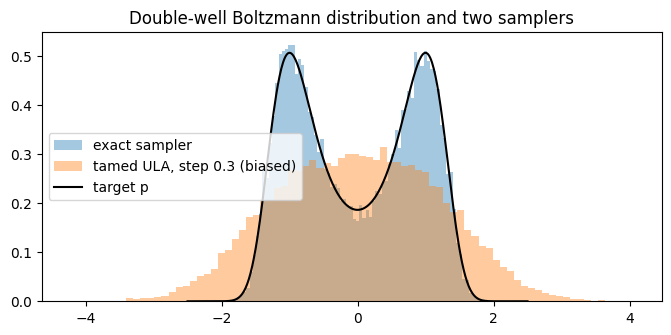

In [2]:
grid = np.linspace(-4, 4, 20001)
dens = np.exp(-((grid**2 - 1.0) ** 2))
cdf = integrate.cumulative_trapezoid(dens, grid, initial=0.0); cdf /= cdf[-1]

def exact_sampler(n):
    return np.interp(rng.random(n), cdf, grid)

def ula_sampler(n, step=0.3, n_steps=300):
    x = rng.standard_normal(n)                  # n independent chains, one draw each
    for _ in range(n_steps):
        g = grad_u(x)
        x = x - step * g / (1 + step * np.abs(g)) + np.sqrt(2 * step) * rng.standard_normal(n)
    return x

xs = np.linspace(-2.5, 2.5, 400)
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(exact_sampler(20000), bins=80, density=True, alpha=0.4, label="exact sampler")
ax.hist(ula_sampler(20000), bins=80, density=True, alpha=0.4, label="tamed ULA, step 0.3 (biased)")
ax.plot(xs, np.exp(-((xs**2 - 1) ** 2)) / np.trapezoid(dens, grid), "k", label="target p")
ax.legend(); ax.set_title("Double-well Boltzmann distribution and two samplers"); plt.show()

exact sampler: rejected at None | tamed ULA: rejected at 230


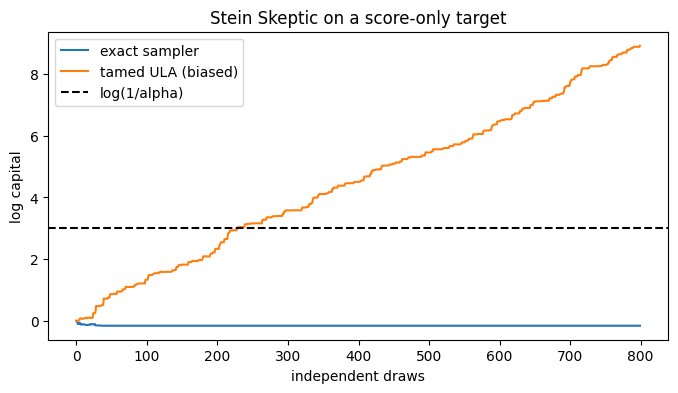

In [3]:
def run(sampler, n=800):
    protocol = BettingProtocol(SteinSkeptic(target, kernel, max_reference_size=300), adaptive)
    path = [protocol.update(np.array([x])).log_e_process for x in sampler(n)]
    return np.array(path), protocol.stopping_time

path_exact, stop_exact = run(exact_sampler)
path_ula, stop_ula = run(ula_sampler)
print("exact sampler: rejected at", stop_exact, "| tamed ULA: rejected at", stop_ula)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(path_exact, label="exact sampler"); ax.plot(path_ula, label="tamed ULA (biased)")
ax.axhline(np.log(1 / ALPHA), color="k", ls="--", label="log(1/alpha)")
ax.set_xlabel("independent draws"); ax.set_ylabel("log capital"); ax.legend(); ax.set_title("Stein Skeptic on a score-only target")
plt.show()

**How to read the chart.** The exact sampler's capital wanders below the alarm line: the test
cannot be fooled into rejecting a correct sampler more than 5% of the time, however long it runs.
The biased sampler is caught after a few hundred independent draws. In a simulation pipeline this is
a continuously running, peek-anytime quality gate: keep drawing until either the sampler is rejected
or you have the samples you need, with no multiple-comparison penalty for checking at every step.

## Model checking with the IMQ kernel: does my data fit my model?

The same test checks *data* against a *model*. Risk models, anomaly detectors and pricing engines
often assume Gaussian noise; real data frequently has heavier tails. For a Gaussian model the score
is globally Lipschitz, so the IMQ kernel of the original SKSD paper can be used. Heavier tails than
the model (Student-t with 3 degrees of freedom) are detected; data from the model are not. The same
pattern applies to monitoring a deployed ML model's residuals for drift away from its training-time
noise assumptions.

N(0,1) data: rejected at None | t(3) data: rejected at 602


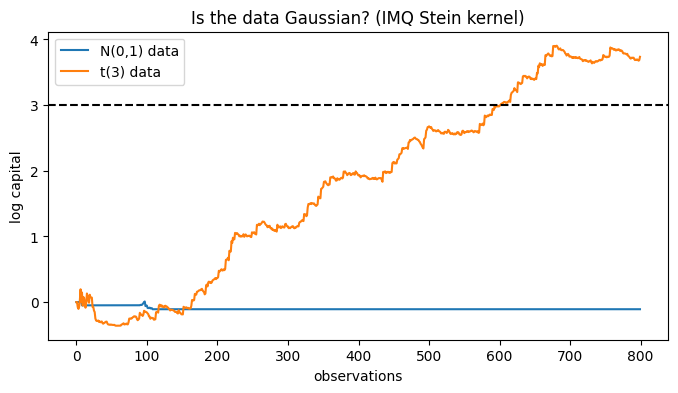

In [4]:
gauss = GaussianTarget(mean=[0.0], cov=[[1.0]])
imq = IMQSteinKernel(dim=1)

def run_gauss(data):
    protocol = BettingProtocol(SteinSkeptic(gauss, imq, max_reference_size=300), adaptive)
    return np.array([protocol.update(np.array([x])).log_e_process for x in data]), protocol.stopping_time

p_null, s_null = run_gauss(rng.standard_normal(800))
p_t, s_t = run_gauss(rng.standard_t(3.0, size=800))
print("N(0,1) data: rejected at", s_null, "| t(3) data: rejected at", s_t)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(p_null, label="N(0,1) data"); ax.plot(p_t, label="t(3) data")
ax.axhline(np.log(1 / ALPHA), color="k", ls="--"); ax.legend(); ax.set_xlabel("observations"); ax.set_ylabel("log capital")
ax.set_title("Is the data Gaussian? (IMQ Stein kernel)"); plt.show()

## Generative AI: catching mode collapse in a sampler for an energy-based model

**Setting.** An energy-based model defines an unnormalised density; here a 2-D Gaussian mixture with
three well-separated modes stands in for it. A sampler is supposed to draw from the model. The classic
failure is **mode collapse**: the sampler under-visits one mode. Likelihood cannot be evaluated
(unknown constant), but the model's score is exact, and the score of a Gaussian mixture is globally
Lipschitz with constant `||Σ^-1|| + ||Σ^-1||^2 D^2 / 4` (D = diameter of the mode set), so the IMQ
kernel can be used with a certified bound.

faithful sampler: rejected at None | mode-collapsed sampler: rejected at None


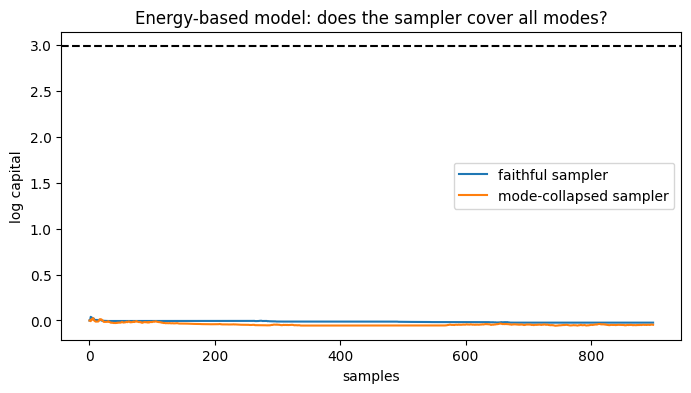

In [5]:
means = np.array([[-3.0, 0.0], [3.0, 0.0], [0.0, 3.5]])
weights = np.array([0.4, 0.4, 0.2])
sigma2 = 0.6

def mixture_score(x):
    d2 = ((x[:, None, :] - means[None, :, :]) ** 2).sum(axis=2)          # (n, 3)
    logits = np.log(weights) - d2 / (2 * sigma2)
    r = np.exp(logits - logits.max(axis=1, keepdims=True)); r /= r.sum(axis=1, keepdims=True)
    return (r @ means - x) / sigma2

diameter = max(np.linalg.norm(a - b) for a in means for b in means)
L_mix = 1 / sigma2 + (1 / sigma2) ** 2 * diameter**2 / 4
from expectation.stein.skeptic import CallableScoreTarget
ebm = CallableScoreTarget(mixture_score, dim=2, lipschitz=L_mix, name="gaussian_mixture_ebm")

def faithful_sampler(n):
    k = rng.choice(3, p=weights, size=n)
    return means[k] + np.sqrt(sigma2) * rng.standard_normal((n, 2))

def collapsed_sampler(n):                       # visits the third mode half as often as it should
    w = np.array([0.45, 0.45, 0.10])
    k = rng.choice(3, p=w, size=n)
    return means[k] + np.sqrt(sigma2) * rng.standard_normal((n, 2))

def run2d(sampler, n=900):
    protocol = BettingProtocol(SteinSkeptic(ebm, IMQSteinKernel(dim=2), max_reference_size=300), adaptive)
    path = [protocol.update(x).log_e_process for x in sampler(n)]
    return np.array(path), protocol.stopping_time

p_ok, s_ok = run2d(faithful_sampler)
p_bad, s_bad = run2d(collapsed_sampler)
print("faithful sampler: rejected at", s_ok, "| mode-collapsed sampler: rejected at", s_bad)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(p_ok, label="faithful sampler"); ax.plot(p_bad, label="mode-collapsed sampler")
ax.axhline(np.log(1 / ALPHA), color="k", ls="--"); ax.legend(); ax.set_xlabel("samples"); ax.set_ylabel("log capital")
ax.set_title("Energy-based model: does the sampler cover all modes?"); plt.show()

## Bayesian models in production: is the MCMC sampler still targeting the posterior?

**Setting.** A credit-risk team runs Bayesian logistic regression. The posterior is known only up to
a constant, but its score is explicit: `s(θ) = -θ/τ² + Σ_i x_i (y_i - σ(x_iᵀθ))`, with a *global*
Lipschitz constant `1/τ² + λ_max(XᵀX)/4`. Two samplers are compared with **one draw per independent
chain** after burn-in: MALA (Metropolis-adjusted, exact in stationarity) and an unadjusted Langevin
sampler with a coarse step (biased — a common shortcut when latency matters).

/var/folders/lp/tst5fj950yj_5_fdx_xmxw100000gp/T/ipykernel_96323/3515592375.py:7: RuntimeWarning: divide by zero encountered in matmul
  z = theta @ X.T
/var/folders/lp/tst5fj950yj_5_fdx_xmxw100000gp/T/ipykernel_96323/3515592375.py:7: RuntimeWarning: overflow encountered in matmul
  z = theta @ X.T
/var/folders/lp/tst5fj950yj_5_fdx_xmxw100000gp/T/ipykernel_96323/3515592375.py:7: RuntimeWarning: invalid value encountered in matmul
  z = theta @ X.T
/var/folders/lp/tst5fj950yj_5_fdx_xmxw100000gp/T/ipykernel_96323/3515592375.py:11: RuntimeWarning: divide by zero encountered in matmul
  z = theta @ X.T
/var/folders/lp/tst5fj950yj_5_fdx_xmxw100000gp/T/ipykernel_96323/3515592375.py:11: RuntimeWarning: overflow encountered in matmul
  z = theta @ X.T
/var/folders/lp/tst5fj950yj_5_fdx_xmxw100000gp/T/ipykernel_96323/3515592375.py:11: RuntimeWarning: invalid value encountered in matmul
  z = theta @ X.T
/var/folders/lp/tst5fj950yj_5_fdx_xmxw100000gp/T/ipykernel_96323/3515592375.py:12: RuntimeWar

/var/folders/lp/tst5fj950yj_5_fdx_xmxw100000gp/T/ipykernel_96323/3515592375.py:11: RuntimeWarning: divide by zero encountered in matmul
  z = theta @ X.T
/var/folders/lp/tst5fj950yj_5_fdx_xmxw100000gp/T/ipykernel_96323/3515592375.py:11: RuntimeWarning: overflow encountered in matmul
  z = theta @ X.T
/var/folders/lp/tst5fj950yj_5_fdx_xmxw100000gp/T/ipykernel_96323/3515592375.py:11: RuntimeWarning: invalid value encountered in matmul
  z = theta @ X.T
/var/folders/lp/tst5fj950yj_5_fdx_xmxw100000gp/T/ipykernel_96323/3515592375.py:12: RuntimeWarning: divide by zero encountered in matmul
  return -theta / tau**2 + (y - 1 / (1 + np.exp(-z))) @ X
/var/folders/lp/tst5fj950yj_5_fdx_xmxw100000gp/T/ipykernel_96323/3515592375.py:12: RuntimeWarning: overflow encountered in matmul
  return -theta / tau**2 + (y - 1 / (1 + np.exp(-z))) @ X
/var/folders/lp/tst5fj950yj_5_fdx_xmxw100000gp/T/ipykernel_96323/3515592375.py:12: RuntimeWarning: invalid value encountered in matmul
  return -theta / tau**2 + (

MALA: rejected at None | coarse ULA: rejected at 153


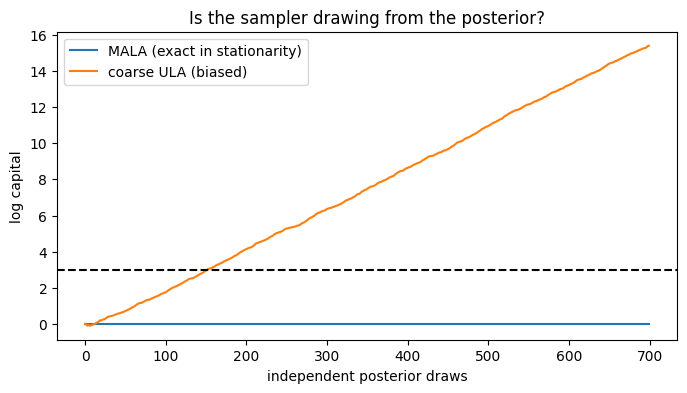

In [6]:
n_obs, dim, tau = 60, 3, 2.0
X = rng.standard_normal((n_obs, dim)); theta_true = np.array([1.0, -0.5, 0.25])
y = (rng.random(n_obs) < 1 / (1 + np.exp(-X @ theta_true))).astype(float)
L_post = 1 / tau**2 + np.linalg.eigvalsh(X.T @ X).max() / 4

def log_post(theta):                                     # unnormalised, vectorised over rows
    z = theta @ X.T
    return -0.5 * (theta**2).sum(axis=1) / tau**2 + (y * z - np.logaddexp(0.0, z)).sum(axis=1)

def post_score(theta):
    z = theta @ X.T
    return -theta / tau**2 + (y - 1 / (1 + np.exp(-z))) @ X

posterior = CallableScoreTarget(post_score, dim=dim, lipschitz=L_post, name="logistic_posterior")

def mala_draws(n, step=0.05, n_steps=400):               # n independent chains, one draw each
    th = 0.3 * rng.standard_normal((n, dim)); lp = log_post(th); sc = post_score(th)
    for _ in range(n_steps):
        prop = th + step * sc + np.sqrt(2 * step) * rng.standard_normal((n, dim))
        lp_p, sc_p = log_post(prop), post_score(prop)
        fwd = -((prop - th - step * sc) ** 2).sum(axis=1) / (4 * step)
        bwd = -((th - prop - step * sc_p) ** 2).sum(axis=1) / (4 * step)
        accept = np.log(rng.random(n)) < lp_p - lp + bwd - fwd
        th[accept], lp[accept], sc[accept] = prop[accept], lp_p[accept], sc_p[accept]
    return th

def coarse_ula_draws(n, step=0.35, n_steps=400):
    th = 0.3 * rng.standard_normal((n, dim))
    for _ in range(n_steps):
        th = th + step * post_score(th) + np.sqrt(2 * step) * rng.standard_normal((n, dim))
    return th

def run_post(draws):
    protocol = BettingProtocol(SteinSkeptic(posterior, IMQSteinKernel(dim=dim), max_reference_size=300), adaptive)
    return np.array([protocol.update(t).log_e_process for t in draws]), protocol.stopping_time

p_mala, s_mala = run_post(mala_draws(700))
p_ula, s_ula = run_post(coarse_ula_draws(700))
print("MALA: rejected at", s_mala, "| coarse ULA: rejected at", s_ula)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(p_mala, label="MALA (exact in stationarity)"); ax.plot(p_ula, label="coarse ULA (biased)")
ax.axhline(np.log(1 / ALPHA), color="k", ls="--"); ax.legend(); ax.set_xlabel("independent posterior draws"); ax.set_ylabel("log capital")
ax.set_title("Is the sampler drawing from the posterior?"); plt.show()

## Where to use this

* **Computational chemistry, materials, pharma**: certify that a molecular-dynamics or Monte Carlo
  sampler reproduces the Boltzmann distribution at the intended temperature, using only the forces.
* **Bayesian production systems**: continuously check that an MCMC or variational sampler still
  targets the posterior after code or hardware changes.
* **Generative AI**: validate energy-based models and score-based samplers, whose densities are
  unnormalised by design — including detecting mode collapse, as above.
* **Credit risk, marketing science, clinical statistics**: any Bayesian model in production whose
  posterior is sampled by MCMC or variational methods; the check needs only the posterior score.
* **Risk and ML monitoring**: detect heavier-than-modelled tails or drift in residuals against a
  parametric noise model, with a peek-anytime guarantee.

What you supply: a score function (or a potential gradient and temperature) and a Lipschitz
constant — global for the IMQ kernel, local for the compactly supported Wendland kernel.